In [1]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [2]:
import kagglehub
import os
import shutil

path = kagglehub.dataset_download("sahandnamvar/phishing-url-detection-111k-urls-22-features")
os.makedirs("../data", exist_ok=True)

for f in os.listdir(path):
    if f.endswith(".csv"):
        shutil.copy(os.path.join(path, f), f"../data/{f}")
        print(f"✅ Downloaded: ml/data/{f}")

c:\Users\Yanovich\Documents\Projects\PhishVigil\phishvigil\ml\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Downloaded: ml/data/Dataset.csv


In [3]:
df = pd.read_csv("../data/Dataset.csv")

In [4]:
df.head()

,url,url_len,dom,dom_len,is_ip,tld,tld_len,subdom_cnt,letter_cnt,digit_cnt,...,under_cnt,letter_ratio,digit_ratio,spec_ratio,is_https,slash_cnt,entropy,path_len,query_len,label
0,https://www.rmit.edu.au/,24,rmit.edu.au,11,0,edu.au,6,1,17,0,...,0,0.708333,0.0,0.291667,1,3,3.709148,1,0,0
1,http://www.latrobe.edu.au/,26,latrobe.edu.au,14,0,edu.au,6,1,19,0,...,0,0.730769,0.0,0.269231,0,3,3.738149,1,0,0
2,https://www.cqu.edu.au/,23,cqu.edu.au,10,0,edu.au,6,1,16,0,...,0,0.695652,0.0,0.304348,1,3,3.609668,1,0,0
3,http://bond.edu.au/,19,bond.edu.au,11,0,edu.au,6,0,13,0,...,0,0.684211,0.0,0.315789,0,3,3.576618,1,0,0
4,http://www.csu.edu.au/,22,csu.edu.au,10,0,edu.au,6,1,15,0,...,0,0.681818,0.0,0.318182,0,3,3.503998,1,0,0


In [5]:
print(df["label"].value_counts(normalize=True))

label
0    0.857633
1    0.142367
Name: proportion, dtype: float64


In [6]:
len(df[df["label"] == 1])

16600

In [7]:
X = df.drop(columns=["url", "label", "dom", "tld"])
y = df["label"]

In [8]:
model = DecisionTreeClassifier(random_state=42)

In [9]:
scores = cross_val_score(model, X, y, cv=4)

In [10]:
print(f"{model.__class__.__name__} mean accuracy:\n{scores.mean():.3f} ± {scores.std():.3f}")

DecisionTreeClassifier mean accuracy:
0.962 ± 0.006


In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [13]:
model.score(X_test, y_test)

0.9717409948542024

In [14]:
y_pred = model.predict(X_test)

In [15]:
print(classification_report(y_test, y_pred, target_names=["safe", "phishing"], digits=4))

              precision    recall  f1-score   support

        safe     0.9829    0.9841    0.9835     19976
    phishing     0.9042    0.8980    0.9011      3344

    accuracy                         0.9717     23320
   macro avg     0.9436    0.9411    0.9423     23320
weighted avg     0.9717    0.9717    0.9717     23320



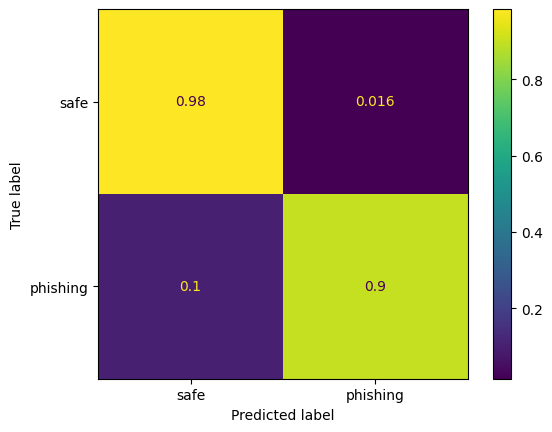

In [16]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["safe", "phishing"], normalize="true")

In [17]:
importance_df = pd.DataFrame(
    {"feature": X.columns, "importance": model.feature_importances_}
).sort_values("importance", ascending=False)

print(importance_df)

         feature  importance
15   digit_ratio    0.330962
17      is_https    0.124007
20      path_len    0.100133
1        dom_len    0.094511
19       entropy    0.089961
18     slash_cnt    0.044279
4     subdom_cnt    0.039508
3        tld_len    0.033625
0        url_len    0.028657
11       dot_cnt    0.028145
12      dash_cnt    0.026535
16    spec_ratio    0.019488
5     letter_cnt    0.014299
14  letter_ratio    0.011422
7    special_cnt    0.005765
21     query_len    0.003009
6      digit_cnt    0.001901
8         eq_cnt    0.001765
13     under_cnt    0.001481
9         qm_cnt    0.000363
10       amp_cnt    0.000184
2          is_ip    0.000000
